# Uday Ankam 
# A20554129

Data Analysis and Final Data Preperation for Training

In [5]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 34.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn style
sns.set(style="whitegrid", palette="deep", font_scale=1.1)

In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.head()

,timestamp,open,close,high,low,volume
0,1569225600,9930.13,9930.13,9930.13,9930.13,0.001
1,1569229200,NaN,NaN,NaN,NaN,0.000
2,1569232800,NaN,NaN,NaN,NaN,0.000
3,1569236400,NaN,NaN,NaN,NaN,0.000
4,1569240000,NaN,NaN,NaN,NaN,0.000


In [6]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
df.set_index('timestamp', inplace=True)

In [7]:
print("Basic Info:")
df.info()
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40555 entries, 2019-09-23 08:00:00 to 2024-05-09 02:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    40478 non-null  float64
 1   close   40478 non-null  float64
 2   high    40478 non-null  float64
 3   low     40478 non-null  float64
 4   volume  40555 non-null  float64
dtypes: float64(5)
memory usage: 1.9 MB

Missing Values:
 open      77
close     77
high      77
low       77
volume     0
dtype: int64

Statistical Summary:
                open         close           high           low        volume
count  40478.000000  40478.000000   40478.000000  40478.000000  40555.000000
mean   29793.985335  29794.376988   29930.795314  29651.448912     27.151419
std    17050.756775  17050.377418   17144.819500  16958.421770     61.041707
min     4156.620000   4152.230000    4608.420000   3649.040000      0.000000
25%    16366.680000  16378.015000   16446.

In [9]:
melted_prices = df[['open', 'close', 'high', 'low']].reset_index().melt(id_vars='timestamp', var_name='Price Type', value_name='Value')

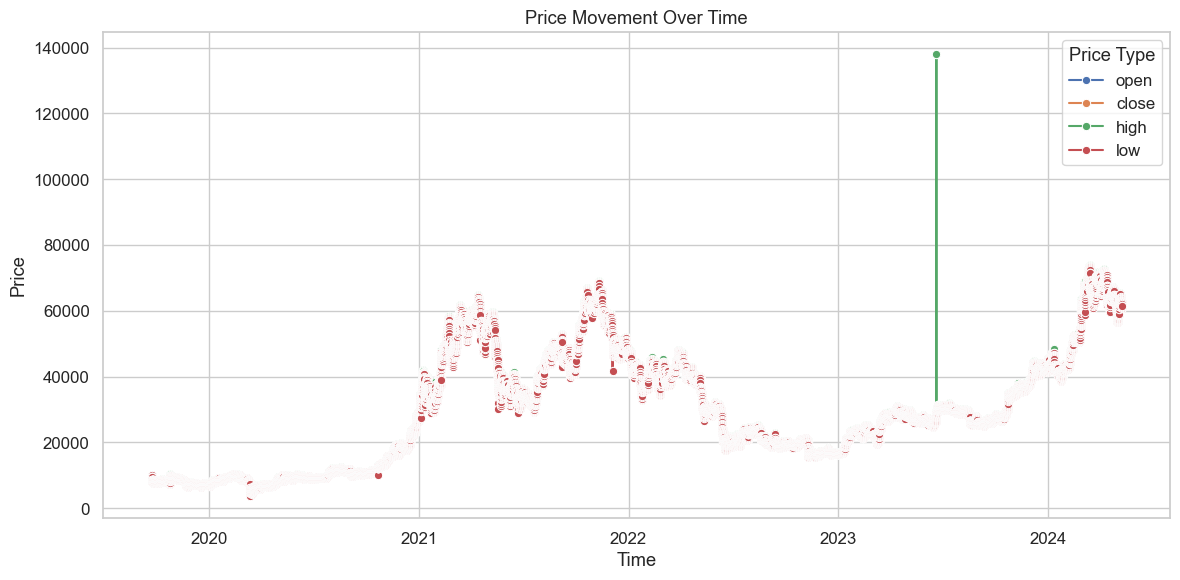

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_prices, x='timestamp', y='Value', hue='Price Type', marker='o')
plt.title("Price Movement Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

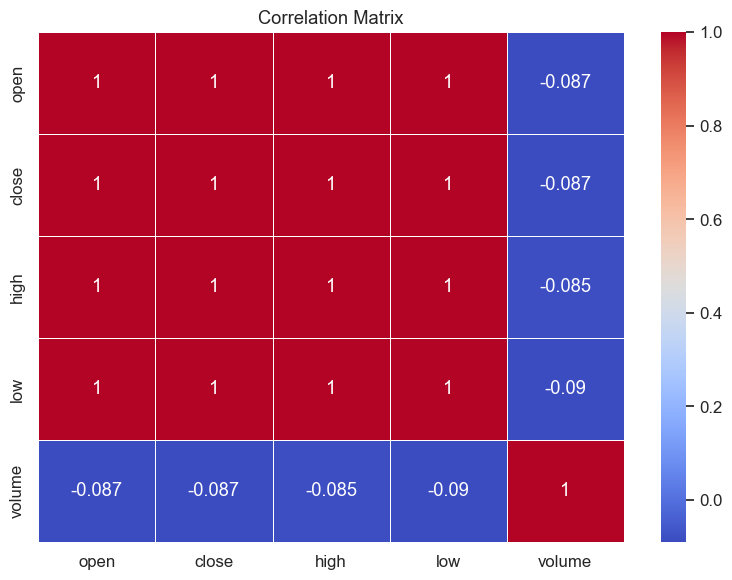

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

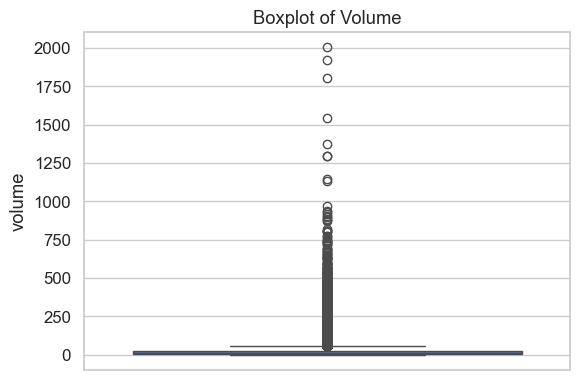

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y='volume')
plt.title("Boxplot of Volume")
plt.tight_layout()
plt.show()

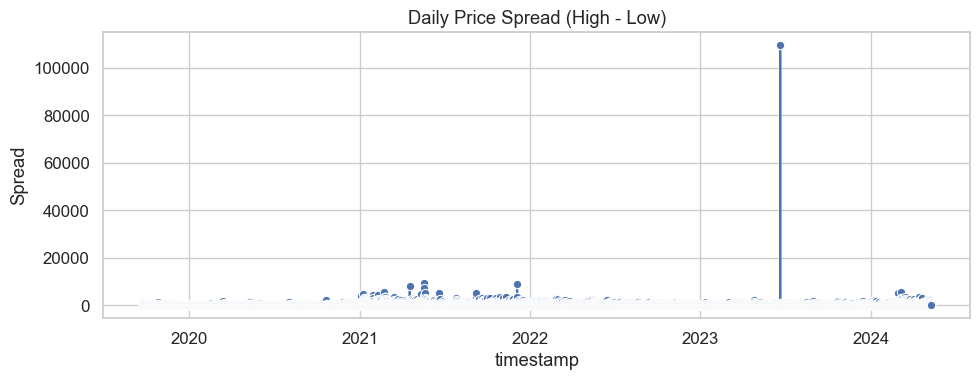

In [13]:
df['spread'] = df['high'] - df['low']
plt.figure(figsize=(10, 4))
sns.lineplot(x=df.index, y=df['spread'], marker='o')
plt.title("Daily Price Spread (High - Low)")
plt.ylabel("Spread")
plt.tight_layout()
plt.show()

In [15]:
# Check time difference between consecutive rows
time_deltas = df.index.to_series().diff().dropna()

# Display unique time differences
print("Unique time intervals between rows:")
print(time_deltas.value_counts().sort_index())

# Most common frequency
most_common_freq = time_deltas.mode()[0]
print(f"\nMost common interval: {most_common_freq}")

# Convert to more readable form (e.g., hours, minutes)
seconds = most_common_freq.total_seconds()

if seconds < 60:
    print(f"Time interval: {seconds} seconds")
elif seconds < 3600:
    print(f"Time interval: {seconds/60:.1f} minutes")
elif seconds < 86400:
    print(f"Time interval: {seconds/3600:.1f} hours")
else:
    print(f"Time interval: {seconds/86400:.1f} days")


Unique time intervals between rows:
timestamp
0 days 01:00:00    40554
Name: count, dtype: int64

Most common interval: 0 days 01:00:00
Time interval: 1.0 hours


In [17]:
sentiment = pd.read_csv('merged_fix_to_hour.csv')

In [18]:
sentiment.head()

,Datetime,BNB_USDT_1h_open,BNB_USDT_1h_high,BNB_USDT_1h_low,BNB_USDT_1h_close,BNB_USDT_1h_volume,BTC_USDT_1h_open,BTC_USDT_1h_high,BTC_USDT_1h_low,BTC_USDT_1h_close,...,VIX_Close ^VIX,VIX_High ^VIX,VIX_Low ^VIX,VIX_Open ^VIX,VIX_Volume ^VIX,funding_rate,fear_gread_index,open_interest,google_trends_buy_crypto,google_trends_bitcoin
0,2023-04-16 00:00:00,333.0455,333.8584,332.3852,332.3852,80.49008,30293.71,30316.77,30275.00,30277.44,...,17.59,17.620001,17.58,17.58,0.0,0.0001,68.0,51018.926,20,33
1,2023-04-16 01:00:00,332.3852,332.3970,330.1126,332.1377,335.75052,30277.44,30277.44,30122.74,30240.00,...,17.59,17.620001,17.58,17.58,0.0,0.0001,68.0,51018.926,20,33
2,2023-04-16 02:00:00,332.1377,332.5400,332.0705,332.2934,88.40229,30240.00,30278.35,30230.01,30267.06,...,17.59,17.620001,17.58,17.58,0.0,0.0001,68.0,51018.926,20,33
3,2023-04-16 03:00:00,332.2934,332.5482,331.8273,332.2009,59.45825,30267.06,30268.67,30233.79,30248.96,...,17.59,17.620001,17.58,17.58,0.0,0.0001,68.0,51018.926,20,33
4,2023-04-16 04:00:00,332.2009,333.0205,331.9821,333.0055,115.57138,30248.96,30307.60,30248.96,30302.08,...,17.59,17.620001,17.58,17.58,0.0,0.0001,68.0,51018.926,20,33
